In [192]:
import pandas as pd

In [193]:
# read in 3pa leaders data
df = pd.read_csv('league_leaders.csv')

In [194]:
df.columns

Index(['Rk', 'Season', 'Team', '3PA/G', 'G', 'W', 'L', 'W/L%', 'MP', 'FG',
       'FGA', '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB',
       'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%',
       'TS%', 'eFG%'],
      dtype='object')

In [195]:
df = df[['Season', 'Team', '3PA/G', '3PA', 'G', 'FTA', 'W/L%']]

In [196]:
# count the values
df.shape

(1314, 7)

In [197]:

df['Team'].unique()

array(['BOS', 'HOU', 'CLE', 'NYK', 'PHO', 'GSW', 'UTA', 'POR', 'CHI',
       'BRK', 'MIN', 'DAL', 'OKC', 'MIL', 'IND', 'SAS', 'CHO', 'TOR',
       'MEM', 'SAC', 'WAS', 'ATL', 'MIA', 'PHI', 'NOP', 'ORL', 'LAC',
       'LAL', 'DEN', 'DET', 'SEA', 'NJN', 'NOH', 'CHH', 'CHA', 'VAN',
       'WSB', 'NOK', 'SDC', 'KCK'], dtype=object)

In [198]:
# map team abbreviations to full team names (add or adjust mappings as needed)
team_names = {
    'BOS': 'Boston Celtics',
    'HOU': 'Houston Rockets',
    'CLE': 'Cleveland Cavaliers',
    'NYK': 'New York Knicks',
    'PHO': 'Phoenix Suns',
    'GSW': 'Golden State Warriors',
    'UTA': 'Utah Jazz',
    'POR': 'Portland Trail Blazers',
    'CHI': 'Chicago Bulls',
    'BRK': 'Brooklyn Nets',
    'MIN': 'Minnesota Timberwolves',
    'DAL': 'Dallas Mavericks',
    'OKC': 'Oklahoma City Thunder',
    'MIL': 'Milwaukee Bucks',
    'IND': 'Indiana Pacers',
    'SAS': 'San Antonio Spurs',
    'CHO': 'Charlotte Hornets',
    'CHA': 'Charlotte Bobcats',
    'CHH': 'Charlotte Hornets',
    'TOR': 'Toronto Raptors',
    'MEM': 'Memphis Grizzlies',
    'SAC': 'Sacramento Kings',
    'WAS': 'Washington Wizards',
    'ATL': 'Atlanta Hawks',
    'MIA': 'Miami Heat',
    'PHI': 'Philadelphia 76ers',
    'NOP': 'New Orleans Pelicans',
    'NOH': 'New Orleans Hornets',
    'ORL': 'Orlando Magic',
    'LAC': 'Los Angeles Clippers',
    'LAL': 'Los Angeles Lakers',
    'DEN': 'Denver Nuggets',
    'DET': 'Detroit Pistons',
    'SEA': 'Seattle SuperSonics',
    'NJN': 'New Jersey Nets',
    'VAN': 'Vancouver Grizzlies',
    'SDC': 'San Diego Clippers',
    'KCK': 'Kansas City Kings',
    'WSB': 'Washington Bullets'
    # leave any uncommon/ambiguous older abbreviations unmapped so they fallback to the code
}

# create new column, falling back to the abbreviation if no mapping exists
df['Team Name'] = df['Team'].map(team_names).fillna(df['Team'])

# show a sample of abbreviations and their mapped names
df[['Team', 'Team Name']].drop_duplicates().sort_values('Team').head(60)

,Team,Team Name
59,ATL,Atlanta Hawks
0,BOS,Boston Celtics
16,BRK,Brooklyn Nets
555,CHA,Charlotte Bobcats
517,CHH,Charlotte Hornets
15,CHI,Chicago Bulls
32,CHO,Charlotte Hornets
4,CLE,Cleveland Cavaliers
19,DAL,Dallas Mavericks
93,DEN,Denver Nuggets


In [199]:
df.dtypes

Season        object
Team          object
3PA/G        float64
3PA            int64
G              int64
FTA            int64
W/L%         float64
Team Name     object
dtype: object

In [200]:
df = df[['Season','Team Name', '3PA/G', 'W/L%']]

df

,Season,Team Name,3PA/G,W/L%
0,2024-25,Boston Celtics,48.2,0.744
1,2025-26,Boston Celtics,46.0,0.400
2,2018-19,Houston Rockets,45.4,0.646
3,2019-20,Houston Rockets,45.3,0.611
4,2025-26,Cleveland Cavaliers,45.2,0.667
...,...,...,...,...
1309,1980-81,San Antonio Spurs,1.0,0.634
1310,1980-81,Detroit Pistons,1.0,0.256
1311,1980-81,Philadelphia 76ers,1.0,0.756
1312,1980-81,Atlanta Hawks,1.0,0.378


In [201]:
import re
import pandas as pd

def season_start_year(s):
    if pd.isna(s):
        return pd.NA
    s = str(s)
    # prefer a 4-digit year if present
    m = re.search(r'(\d{4})', s)
    if m:
        return int(m.group(1))
    # fallback to two-digit start year like "99-00" or "05-06"
    m = re.search(r'(\d{2})\D+\d{2}', s)
    if m:
        yy = int(m.group(1))
        return 1900 + yy if yy >= 70 else 2000 + yy
    return pd.NA

# add integer start year (e.g. "2025-2026" or "2025-26" -> 2025)
df['Season'] = df['Season'].apply(season_start_year).astype('Int64')

In [202]:
df.to_csv('every_team_3pa_leaders.csv', index=False)

In [203]:
# restrict df to the top 150 team-season entries by 3PA/G (highest 3PA/G)
df = df.sort_values('3PA/G', ascending=False).head(150).reset_index(drop=True)

# quick check
df.shape, df['3PA/G'].min(), df['3PA/G'].max()

((150, 4), 33.5, 48.2)

In [204]:
df.to_csv('top_150_3pa.csv', index=False)

In [205]:
shooting = pd.read_csv('shooting.csv')

shooting

,Rk,Team,G,MP,FG%,Dist.,Unnamed: 6,2P,0-3,3-10,...,Md.,Unnamed: 26,%FGA.1,Md..1,Unnamed: 29,%3PA,3P%,Unnamed: 32,Att.,Md..2
0,1.0,Atlanta Hawks,82,19780,0.472,13.7,NaN,0.590,0.257,0.228,...,484,NaN,0.263,1089,NaN,0.277,0.405,NaN,20.0,1.0
1,2.0,Boston Celtics*,82,19830,0.462,17.0,NaN,0.464,0.179,0.168,...,352,NaN,0.213,936,NaN,0.187,0.393,NaN,12.0,0.0
2,3.0,Brooklyn Nets,82,19780,0.437,14.7,NaN,0.542,0.228,0.214,...,305,NaN,0.277,1021,NaN,0.265,0.348,NaN,14.0,0.0
3,4.0,Chicago Bulls,82,19755,0.470,14.6,NaN,0.543,0.264,0.187,...,277,NaN,0.291,1284,NaN,0.250,0.389,NaN,15.0,2.0
4,5.0,Charlotte Hornets,82,19755,0.430,14.6,NaN,0.570,0.226,0.223,...,379,NaN,0.249,949,NaN,0.235,0.369,NaN,22.0,0.0
5,6.0,Cleveland Cavaliers*,82,19755,0.491,14.9,NaN,0.543,0.241,0.190,...,444,NaN,0.234,1005,NaN,0.245,0.401,NaN,11.0,1.0
6,7.0,Dallas Mavericks,82,19730,0.479,13.9,NaN,0.611,0.227,0.230,...,372,NaN,0.252,1076,NaN,0.261,0.379,NaN,15.0,0.0
7,8.0,Denver Nuggets*,82,19855,0.506,13.2,NaN,0.644,0.265,0.237,...,465,NaN,0.318,1406,NaN,0.215,0.431,NaN,38.0,2.0
8,9.0,Detroit Pistons*,82,19805,0.476,13.8,NaN,0.606,0.227,0.251,...,558,NaN,0.264,1041,NaN,0.240,0.379,NaN,20.0,0.0
9,10.0,Golden State Warriors*,82,19730,0.451,15.4,NaN,0.531,0.168,0.252,...,339,NaN,0.294,1197,NaN,0.238,0.389,NaN,22.0,1.0


In [206]:
shot_distance = pd.read_excel('shot_distance.xlsx')

shot_distance

,Season,2 pointers,0 to 3 feet,3 to 10 feet,10 to 16 feet,16 feet to 3P,3P
0,2025,0.583,0.231,0.209,0.093,0.051,0.417
1,2024,0.579,0.226,0.214,0.091,0.048,0.421
2,2023,0.605,0.241,0.211,0.096,0.058,0.395
3,2022,0.613,0.245,0.206,0.096,0.063,0.387
4,2021,0.601,0.239,0.193,0.094,0.070,0.399
5,2020,0.608,0.254,0.186,0.096,0.072,0.392
6,2019,0.616,0.282,0.165,0.093,0.077,0.384
7,2018,0.641,0.292,0.162,0.096,0.092,0.359
8,2017,0.663,0.281,0.156,0.106,0.120,0.337
9,2016,0.684,0.290,0.152,0.099,0.142,0.316


In [207]:
import pandas as pd

# multiply every numeric column by 100 except any column named "Season" (case-insensitive)

def multiply_except_season(df):
    if not isinstance(df, pd.DataFrame):
        return df
    cols_to_process = [c for c in df.columns if str(c).lower() != 'season']
    numeric_cols = [c for c in cols_to_process if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        df[numeric_cols] = df[numeric_cols] * 100
    return df

# apply to shot_distance dataframe
shot_distance = multiply_except_season(shot_distance)

shot_distance

,Season,2 pointers,0 to 3 feet,3 to 10 feet,10 to 16 feet,16 feet to 3P,3P
0,2025,58.3,23.1,20.9,9.3,5.1,41.7
1,2024,57.9,22.6,21.4,9.1,4.8,42.1
2,2023,60.5,24.1,21.1,9.6,5.8,39.5
3,2022,61.3,24.5,20.6,9.6,6.3,38.7
4,2021,60.1,23.9,19.3,9.4,7.0,39.9
5,2020,60.8,25.4,18.6,9.6,7.2,39.2
6,2019,61.6,28.2,16.5,9.3,7.7,38.4
7,2018,64.1,29.2,16.2,9.6,9.2,35.9
8,2017,66.3,28.1,15.6,10.6,12.0,33.7
9,2016,68.4,29.0,15.2,9.9,14.2,31.6


In [208]:
# save to csv
shot_distance.to_csv('shot_distance.csv', index=False)

In [209]:
league_avg = pd.read_csv('league_per_game.csv')

In [210]:
league_avg.columns

Index(['Rk', 'Season', 'Lg', 'Age', 'Ht', 'Wt', 'G', 'MP', 'FG', 'FGA', '3P',
       '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'FG%', '3P%', 'FT%', 'Pace', 'eFG%', 'TOV%', 'ORB%',
       'FT/FGA', 'ORtg', 'TS%'],
      dtype='object')

In [211]:
league_avg

,Rk,Season,Lg,Age,Ht,Wt,G,MP,FG,FGA,...,FG%,3P%,FT%,Pace,eFG%,TOV%,ORB%,FT/FGA,ORtg,TS%
0,1,2025-26,NBA,26.4,6-7,216,156,241.6,41.6,89.0,...,0.467,0.357,0.789,100.6,0.542,13.3,26.5,0.229,115.4,0.582
1,2,2024-25,NBA,26.3,6-7,215,1230,241.3,41.7,89.2,...,0.467,0.360,0.780,98.8,0.543,12.6,25.2,0.189,114.5,0.576
2,3,2023-24,NBA,26.4,6-7,216,1230,241.4,42.2,88.9,...,0.474,0.366,0.784,98.5,0.547,12.1,24.2,0.192,115.3,0.580
3,4,2022-23,NBA,26.1,6-6,216,1230,241.8,42.0,88.3,...,0.475,0.361,0.782,99.2,0.545,12.5,24.0,0.208,114.8,0.581
4,5,2021-22,NBA,26.1,6-6,215,1230,241.4,40.6,88.1,...,0.461,0.354,0.775,98.2,0.532,12.3,23.2,0.192,112.0,0.566
5,6,2020-21,NBA,26.1,6-6,217,1080,241.4,41.2,88.4,...,0.466,0.367,0.778,99.2,0.538,12.4,22.2,0.192,112.3,0.572
6,7,2019-20,NBA,26.1,6-6,218,1059,241.8,40.9,88.8,...,0.460,0.358,0.773,100.3,0.529,12.8,22.5,0.201,110.6,0.565
7,8,2018-19,NBA,26.3,6-6,219,1230,241.6,41.1,89.2,...,0.461,0.355,0.766,100.0,0.524,12.4,22.9,0.198,110.4,0.560
8,9,2017-18,NBA,26.4,6-7,220,1230,241.4,39.6,86.1,...,0.460,0.362,0.767,97.3,0.521,13.0,22.3,0.193,108.6,0.556
9,10,2016-17,NBA,26.6,6-7,221,1230,241.6,39.0,85.4,...,0.457,0.358,0.772,96.4,0.514,12.7,23.3,0.209,108.8,0.552


In [212]:
# apply season_start_year function to the 'Season' column
league_avg['Season'] = league_avg['Season'].apply(season_start_year).astype('Int64')

league_avg

,Rk,Season,Lg,Age,Ht,Wt,G,MP,FG,FGA,...,FG%,3P%,FT%,Pace,eFG%,TOV%,ORB%,FT/FGA,ORtg,TS%
0,1,2025,NBA,26.4,6-7,216,156,241.6,41.6,89.0,...,0.467,0.357,0.789,100.6,0.542,13.3,26.5,0.229,115.4,0.582
1,2,2024,NBA,26.3,6-7,215,1230,241.3,41.7,89.2,...,0.467,0.360,0.780,98.8,0.543,12.6,25.2,0.189,114.5,0.576
2,3,2023,NBA,26.4,6-7,216,1230,241.4,42.2,88.9,...,0.474,0.366,0.784,98.5,0.547,12.1,24.2,0.192,115.3,0.580
3,4,2022,NBA,26.1,6-6,216,1230,241.8,42.0,88.3,...,0.475,0.361,0.782,99.2,0.545,12.5,24.0,0.208,114.8,0.581
4,5,2021,NBA,26.1,6-6,215,1230,241.4,40.6,88.1,...,0.461,0.354,0.775,98.2,0.532,12.3,23.2,0.192,112.0,0.566
5,6,2020,NBA,26.1,6-6,217,1080,241.4,41.2,88.4,...,0.466,0.367,0.778,99.2,0.538,12.4,22.2,0.192,112.3,0.572
6,7,2019,NBA,26.1,6-6,218,1059,241.8,40.9,88.8,...,0.460,0.358,0.773,100.3,0.529,12.8,22.5,0.201,110.6,0.565
7,8,2018,NBA,26.3,6-6,219,1230,241.6,41.1,89.2,...,0.461,0.355,0.766,100.0,0.524,12.4,22.9,0.198,110.4,0.560
8,9,2017,NBA,26.4,6-7,220,1230,241.4,39.6,86.1,...,0.460,0.362,0.767,97.3,0.521,13.0,22.3,0.193,108.6,0.556
9,10,2016,NBA,26.6,6-7,221,1230,241.6,39.0,85.4,...,0.457,0.358,0.772,96.4,0.514,12.7,23.3,0.209,108.8,0.552


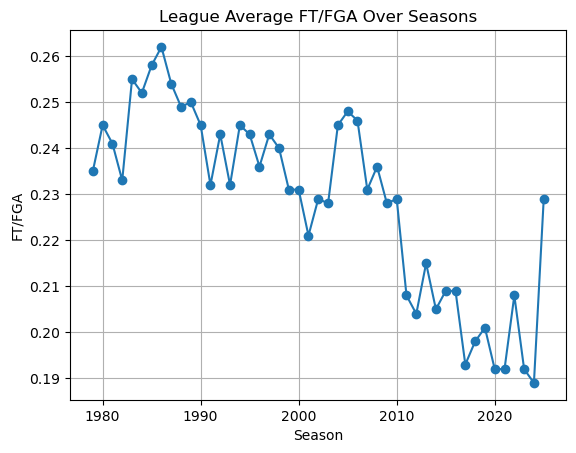

In [213]:
# plot the FT/FGA over seasons
import matplotlib.pyplot as plt
plt.plot(league_avg['Season'], league_avg['FT/FGA'], marker='o')
plt.xlabel('Season')
plt.ylabel('FT/FGA')
plt.title('League Average FT/FGA Over Seasons')
plt.grid()
plt.show()  

In [214]:
ft_fg_avg = league_avg[['Season', 'FT/FGA']]

league_avg.to_csv('league_ft_fga_avg.csv', index=False)

In [215]:
league_avg.to_csv('league_per_game_clean.csv', index=False)

### Missed threes and free throws

In [216]:
shots = league_avg.copy()

# Missed threes and free throws
shots['Missed 3s'] = shots['3PA'] - shots['3P']

In [217]:
shots.columns

Index(['Rk', 'Season', 'Lg', 'Age', 'Ht', 'Wt', 'G', 'MP', 'FG', 'FGA', '3P',
       '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'FG%', '3P%', 'FT%', 'Pace', 'eFG%', 'TOV%', 'ORB%',
       'FT/FGA', 'ORtg', 'TS%', 'Missed 3s'],
      dtype='object')

In [218]:
shots = shots[['Season', 'FG', 'FGA', '3P',
       '3PA', 'FT', 'FTA', 'Missed 3s']]

In [219]:
shots

,Season,FG,FGA,3P,3PA,FT,FTA,Missed 3s
0,2025,41.6,89.0,13.3,37.1,20.4,25.8,23.8
1,2024,41.7,89.2,13.5,37.6,16.9,21.7,24.1
2,2023,42.2,88.9,12.8,35.1,17.0,21.7,22.3
3,2022,42.0,88.3,12.3,34.2,18.4,23.5,21.9
4,2021,40.6,88.1,12.4,35.2,16.9,21.9,22.8
5,2020,41.2,88.4,12.7,34.6,17.0,21.8,21.9
6,2019,40.9,88.8,12.2,34.1,17.9,23.1,21.9
7,2018,41.1,89.2,11.4,32.0,17.7,23.1,20.6
8,2017,39.6,86.1,10.5,29.0,16.6,21.7,18.5
9,2016,39.0,85.4,9.7,27.0,17.8,23.1,17.3


In [220]:
# caclulate total shots as FGA + FTA
shots['total_shots'] = shots['FGA'] + shots['FTA']

# calculate two-point shots made and missed
shots['2PM'] = shots['FG'] - shots['3P']
shots['2PA'] = shots['FGA'] - shots['3PA']
shots['Missed 2s'] = shots['2PA'] - shots['2PM']

shots['2PM_total'] = shots['2PM'] * 2
shots['3PM_total'] = shots['3P'] * 2
shots['FT_total'] = shots['FTA'] * 2
shots['Missed 2s_total'] = shots['Missed 2s'] * 2
shots['Missed 3s_total'] = shots['Missed 3s'] * 2

# round all numeric columns to 2 decimal places
numeric_cols = shots.select_dtypes(include='number').columns

shots[numeric_cols] = shots[numeric_cols].round(2)

shots

,Season,FG,FGA,3P,3PA,FT,FTA,Missed 3s,total_shots,2PM,2PA,Missed 2s,2PM_total,3PM_total,FT_total,Missed 2s_total,Missed 3s_total
0,2025,41.6,89.0,13.3,37.1,20.4,25.8,23.8,114.8,28.3,51.9,23.6,56.6,26.6,51.6,47.2,47.6
1,2024,41.7,89.2,13.5,37.6,16.9,21.7,24.1,110.9,28.2,51.6,23.4,56.4,27.0,43.4,46.8,48.2
2,2023,42.2,88.9,12.8,35.1,17.0,21.7,22.3,110.6,29.4,53.8,24.4,58.8,25.6,43.4,48.8,44.6
3,2022,42.0,88.3,12.3,34.2,18.4,23.5,21.9,111.8,29.7,54.1,24.4,59.4,24.6,47.0,48.8,43.8
4,2021,40.6,88.1,12.4,35.2,16.9,21.9,22.8,110.0,28.2,52.9,24.7,56.4,24.8,43.8,49.4,45.6
5,2020,41.2,88.4,12.7,34.6,17.0,21.8,21.9,110.2,28.5,53.8,25.3,57.0,25.4,43.6,50.6,43.8
6,2019,40.9,88.8,12.2,34.1,17.9,23.1,21.9,111.9,28.7,54.7,26.0,57.4,24.4,46.2,52.0,43.8
7,2018,41.1,89.2,11.4,32.0,17.7,23.1,20.6,112.3,29.7,57.2,27.5,59.4,22.8,46.2,55.0,41.2
8,2017,39.6,86.1,10.5,29.0,16.6,21.7,18.5,107.8,29.1,57.1,28.0,58.2,21.0,43.4,56.0,37.0
9,2016,39.0,85.4,9.7,27.0,17.8,23.1,17.3,108.5,29.3,58.4,29.1,58.6,19.4,46.2,58.2,34.6


In [221]:
shots = shots[['Season', 'FT_total','Missed 3s_total','Missed 2s_total','3PM_total', '2PM_total']]

shots.columns = ['Season', 'Free Throws', 'Missed 3s', 'Missed 2s', 'Made 3s', 'Made 2s']

In [222]:
shots.to_csv('shots_clean.csv', index=False)